<a href="https://colab.research.google.com/github/BhoomiMahna/Dysarthria_Speech_Project/blob/Tacotron2/Tacotron2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [10]:
import os
print(os.listdir('/content/drive/MyDrive/'))

['Colab Notebooks', 'dysarthria_project', 'IMG-20250204-WA0075.jpg', 'IMG-20250204-WA0078.jpg', 'Screenshot_20250205_163334_Chrome.jpg', 'VID-20241114-WA0047.mp4', 'inbound5758457001045093226.jpg', 'web.gdoc', 'SANVARDHAN SOLN.pptx', 'Screenshots', 'hackathon.pptx', '20250411_173950.jpg', 'Screenshot_20250425_001157_GPay.jpg', 'Bhoomi Mahna.jpg', '2025 Summer Project Details.pdf', 'house prices.gsheet', 'Bhoomi_Mahna_Resume (1) (1).pdf', 'Bhoomi_Mahna_Resume (1).pdf', 'Bhoomi_Mahna_Resume.pdf', 'Classroom', '2Q25 STUDENT DATA.gsheet', 'Copy_of_speech_tts.ipynb', 'dysarthria_project.zip', 'Leetcode Log.gsheet', '20251124_010209 (3 files merged) (1).pdf', 'Untitled spreadsheet.gsheet', 'UASpeech_F02_Project', 'UASpeech database']


In [15]:
import os
SOURCE_PATH = '/content/drive/MyDrive/UASpeech database/audio/F02'

all_files = os.listdir(SOURCE_PATH)
# This extracts the 'M' part from filenames like 'F02_B1_UW29_M3.wav'
mics_found = sorted(list(set([f.split('_')[-1].replace('.wav', '') for f in all_files if '_M' in f])))

print(f"Microphones available in this folder: {mics_found}")

Microphones available in this folder: ['M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8']


In [16]:
import os
import shutil
from tqdm import tqdm

SOURCE_PATH = '/content/drive/MyDrive/UASpeech database/audio/F02'
DEST_PATH = '/content/drive/MyDrive/UASpeech_F02_Project/audio'
os.makedirs(DEST_PATH, exist_ok=True)

all_files = os.listdir(SOURCE_PATH)

# Identify the best microphone (prefer M1, then M2, then M3...)
mics = sorted(list(set([f.split('_')[-1].replace('.wav', '') for f in all_files if '_M' in f])))
best_mic = mics[0] # Takes the lowest number found

print(f"Targeting Microphone: {best_mic}")

# Filter for Speaker F02 and the chosen Microphone
files_to_copy = [f for f in all_files if f.upper().startswith('F02') and f'_{best_mic}.wav' in f]

print(f"✅ Found {len(files_to_copy)} files for {best_mic}. Starting copy...")

for f in tqdm(files_to_copy):
    src = os.path.join(SOURCE_PATH, f)
    dst = os.path.join(DEST_PATH, f)
    if not os.path.exists(dst):
        shutil.copy2(src, dst)

print(f"\n🎉 DONE! {len(files_to_copy)} files copied to {DEST_PATH}")

Targeting Microphone: M2
✅ Found 765 files for M2. Starting copy...


100%|██████████| 765/765 [10:12<00:00,  1.25it/s]


🎉 DONE! 765 files copied to /content/drive/MyDrive/UASpeech_F02_Project/audio


In [17]:
import os
import shutil

# Paths
SHARED_ROOT = '/content/drive/MyDrive/UASpeech database'
PROJECT_ROOT = '/content/drive/MyDrive/UASpeech_F02_Project'

# Create a metadata folder inside your project
metadata_dir = os.path.join(PROJECT_ROOT, 'metadata')
os.makedirs(metadata_dir, exist_ok=True)

# List of important files to pull
# We will search for these specifically
targets = {
    'wordlist': 'speaker_wordlist.xls',
    'dictionary': 'dict/M16/M16_aligned_phones.dict'
}

print("📂 Copying metadata files...")

for key, relative_path in targets.items():
    src = os.path.join(SHARED_ROOT, relative_path)
    dst = os.path.join(metadata_dir, os.path.basename(relative_path))

    if os.path.exists(src):
        shutil.copy2(src, dst)
        print(f"✅ Successfully copied {key}: {os.path.basename(src)}")
    else:
        # Fallback: sometimes files are in the root of the shared folder
        fallback_src = os.path.join(SHARED_ROOT, os.path.basename(relative_path))
        if os.path.exists(fallback_src):
            shutil.copy2(fallback_src, dst)
            print(f"✅ Successfully copied {key} (found in root): {os.path.basename(src)}")
        else:
            print(f"⚠️ Warning: Could not find {key}. You may need to locate it manually.")

print(f"\n✨ All metadata is now organized in: {metadata_dir}")

📂 Copying metadata files...
⚠️ Warning: Could not find wordlist. You may need to locate it manually.
⚠️ Warning: Could not find dictionary. You may need to locate it manually.

✨ All metadata is now organized in: /content/drive/MyDrive/UASpeech_F02_Project/metadata


In [18]:
import os
import librosa
import soundfile as sf
import numpy as np
from tqdm import tqdm

# --- CONFIGURATION ---
input_dir = '/content/drive/MyDrive/UASpeech_F02_Project/audio'
output_dir = '/content/drive/MyDrive/UASpeech_F02_Project/processed'
target_sr = 22050  # Required for Tacotron 2
trim_db = 35       # Sensitivity for silence; 35-40 is good for dysarthric speech

os.makedirs(output_dir, exist_ok=True)

audio_files = [f for f in os.listdir(input_dir) if f.endswith('.wav')]

print(f"🔄 Resampling and Trimming {len(audio_files)} files...")

for filename in tqdm(audio_files):
    input_path = os.path.join(input_dir, filename)
    output_path = os.path.join(output_dir, filename)

    try:
        # 1. Load and Resample to 22,050 Hz
        audio, sr = librosa.load(input_path, sr=target_sr)

        # 2. Trim Silence (Beginning and End)
        # yt = trimmed audio, index = where the sound actually starts/ends
        yt, _ = librosa.effects.trim(audio, top_db=trim_db)

        # 3. Normalize Volume (prevents some files being too quiet)
        if len(yt) > 0:
            yt = yt / np.max(np.abs(yt))

        # 4. Save to the 'processed' folder
        sf.write(output_path, yt, target_sr)

    except Exception as e:
        print(f"⚠️ Error with {filename}: {e}")

print(f"\n✅ Done! Cleaned audio is in: {output_dir}")

🔄 Resampling and Trimming 765 files...


100%|██████████| 765/765 [00:31<00:00, 24.08it/s]


✅ Done! Cleaned audio is in: /content/drive/MyDrive/UASpeech_F02_Project/processed


In [19]:
!pip install xlrd

In [22]:
import os
import shutil

# Paths
SHARED_ROOT = '/content/drive/MyDrive/UASpeech database'
PROJECT_META = '/content/drive/MyDrive/UASpeech_F02_Project/metadata'

os.makedirs(PROJECT_META, exist_ok=True)

found_excel = False

print("🔍 Searching for speaker_wordlist.xls in the shared folder...")
for root, dirs, files in os.walk(SHARED_ROOT):
    for f in files:
        if f.lower() == 'speaker_wordlist.xls':
            src_path = os.path.join(root, f)
            dst_path = os.path.join(PROJECT_META, f)
            shutil.copy2(src_path, dst_path)
            print(f"✅ Found and copied: {src_path}")
            found_excel = True
            break
    if found_excel: break

if not found_excel:
    print("❌ Could not find the file. Please check if 'speaker_wordlist.xls' is in the root of the Shared Folder.")

🔍 Searching for speaker_wordlist.xls in the shared folder...
✅ Found and copied: /content/drive/MyDrive/UASpeech database/audio/speaker_wordlist.xls


In [25]:
import pandas as pd
import os
import random

# --- SET PATHS ---
project_root = '/content/drive/MyDrive/UASpeech_F02_Project'
excel_path = os.path.join(project_root, 'metadata/speaker_wordlist.xls')
processed_dir = os.path.join(project_root, 'processed')

if not os.path.exists(excel_path):
    print("❌ Error: speaker_wordlist.xls not found.")
else:
    # 1. Load the Word Mapping Sheet
    df = pd.read_excel(excel_path, sheet_name='Word_filename')

    # 2. Map 'FILE NAME' to 'WORD'
    # Based on your output: 'FILE NAME' contains the ID (CW1) and 'WORD' is the text (Computer)
    word_map = {str(row['FILE NAME']).strip(): str(row['WORD']).strip() for _, row in df.iterrows()}

    # 3. Match Audio Files
    file_data = []
    processed_files = [f for f in os.listdir(processed_dir) if f.endswith('.wav')]

    print(f"🔄 Mapping {len(processed_files)} files using 'FILE NAME' column...")

    for filename in processed_files:
        # Example: F02_B1_CW1_M2.wav -> parts[2] is 'CW1'
        parts = filename.split('_')
        if len(parts) >= 3:
            word_id = parts[2]

            transcript = word_map.get(word_id)

            if transcript:
                full_path = os.path.join(processed_dir, filename)
                # Tacotron 2 format: /path/to/audio.wav|Transcript
                file_data.append(f"{full_path}|{transcript}")

    # 4. Save 90/10 Split
    if len(file_data) > 0:
        random.seed(42)
        random.shuffle(file_data)

        split_point = int(len(file_data) * 0.9)

        with open(os.path.join(project_root, 'f02_train.txt'), 'w') as f:
            f.write('\n'.join(file_data[:split_point]))

        with open(os.path.join(project_root, 'f02_val.txt'), 'w') as f:
            f.write('\n'.join(file_data[split_point:]))

        print(f"\n✨ SUCCESS! Created filelists with {len(file_data)} entries.")
        print(f"Sample line: {file_data[0]}")
    else:
        print("❌ No matches found. Let's debug IDs:")
        print(f"Sample ID from filename: {processed_files[0].split('_')[2]}")
        print(f"Sample IDs from Excel: {list(word_map.keys())[:5]}")

🔄 Mapping 765 files using 'FILE NAME' column...

✨ SUCCESS! Created filelists with 465 entries.
Sample line: /content/drive/MyDrive/UASpeech_F02_Project/processed/F02_B1_CW8_M2.wav|you


In [27]:
# Check for unique characters in your transcripts
all_text = ""
with open('/content/drive/MyDrive/UASpeech_F02_Project/f02_train.txt', 'r') as f:
    for line in f:
        all_text += line.split('|')[1].strip()

chars = sorted(list(set(all_text)))
print(f"Characters your model will learn: {chars}")

Characters your model will learn: ['-', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y']


In [29]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import IPython.display as ipd

# Load the first line from your training list
with open('/content/drive/MyDrive/UASpeech_F02_Project/f02_train.txt', 'r') as f:
    sample_line = f.readline().strip()

audio_path, transcript = sample_line.split('|')

print(f"Playing: {transcript}")
print(f"File: {audio_path}")

# Load the audio
y, sr = librosa.load(audio_path, sr=22050)
ipd.Audio(y, rate=sr)

Playing: you
File: /content/drive/MyDrive/UASpeech_F02_Project/processed/F02_B1_CW8_M2.wav


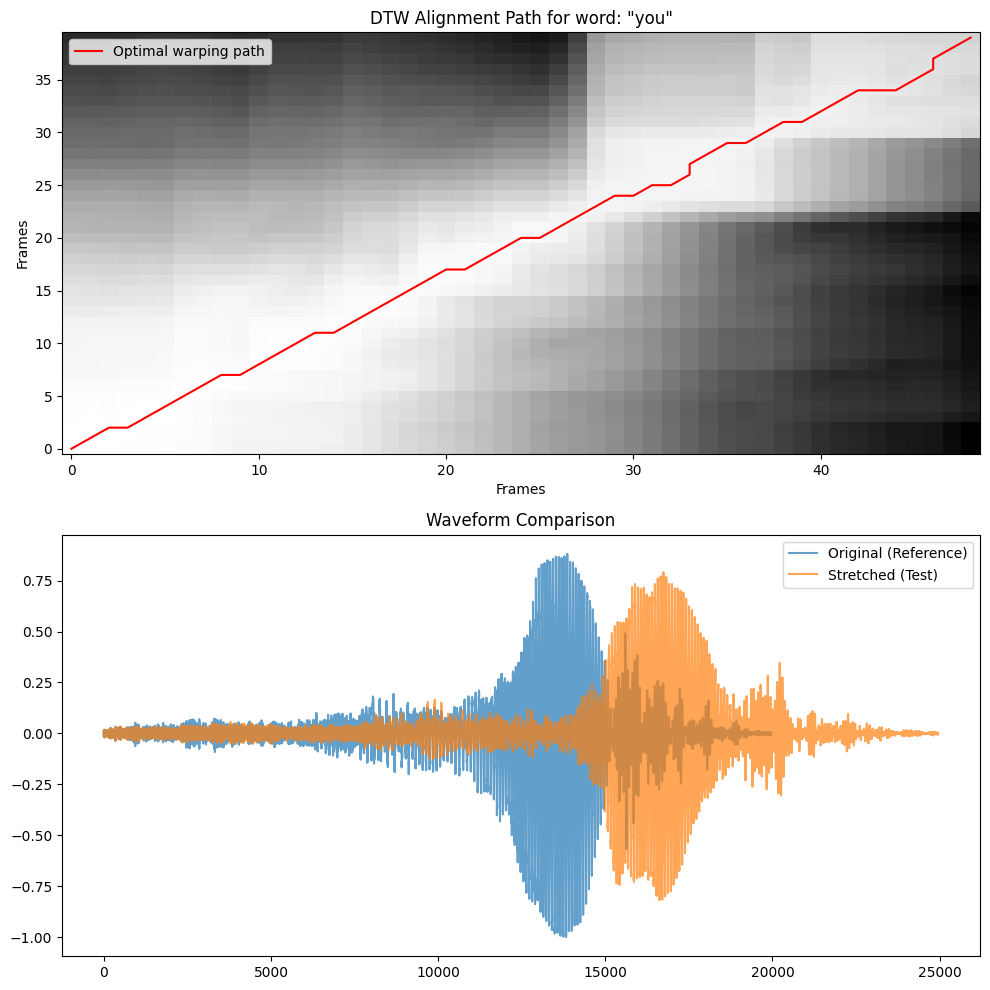

In [30]:
# For this example, we will compare the sample to a slightly "stretched" version of itself
# to visualize how DTW finds the optimal alignment path.
y_ref = y.copy()
y_test = librosa.effects.time_stretch(y, rate=0.8) # Simulating a slower dysarthric utterance

# Extract features (Chromagram or MFCCs are best for DTW)
hop_length = 512
x_1 = librosa.feature.chroma_stft(y=y_ref, sr=sr, hop_length=hop_length)
x_2 = librosa.feature.chroma_stft(y=y_test, sr=sr, hop_length=hop_length)

# Calculate DTW
D, wp = librosa.sequence.dtw(X=x_1, Y=x_2, metric='cosine')

# Plotting the DTW Alignment
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
librosa.display.specshow(D, x_axis='frames', y_axis='frames', cmap='gray_r')
plt.plot(wp[:, 1], wp[:, 0], label='Optimal warping path', color='r')
plt.title(f'DTW Alignment Path for word: "{transcript}"')
plt.legend()

# Visualizing the cost matrix
plt.subplot(2, 1, 2)
plt.plot(y_ref, label='Original (Reference)', alpha=0.7)
plt.plot(y_test, label='Stretched (Test)', alpha=0.7)
plt.title('Waveform Comparison')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
import os

# Path to your training file
train_path = '/content/drive/MyDrive/UASpeech_F02_Project/f02_train.txt'

unique_words = set()
with open(train_path, 'r') as f:
    for line in f:
        # Get the transcript part after the '|'
        transcript = line.split('|')[1].strip().upper()
        # Remove basic punctuation
        clean_text = transcript.replace('.', '').replace(',', '').replace('?', '')
        unique_words.update(clean_text.split())

print(f"Total unique words spoken by F02: {len(unique_words)}")

Total unique words spoken by F02: 155


In [34]:
!pip install g2p_en
from g2p_en import G2p
import os

# 1. Extract words from your F02 Training Transcripts
train_path = '/content/drive/MyDrive/UASpeech_F02_Project/f02_train.txt'
unique_words = set()

with open(train_path, 'r') as f:
    for line in f:
        transcript = line.split('|')[1].strip().upper()
        clean_text = transcript.translate(str.maketrans('', '', '.,?!'))
        unique_words.update(clean_text.split())

print(f"Total unique words to process: {len(unique_words)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 52.4 MB/s eta 0:00:00
  Created wheel for distance: filename=Distance-0.1.3-py3-none-any.whl size=16256 sha256=a083a0344d7dd80364f90e846368d7f399b4813cd065120c887a519819642bb1
  Stored in directory: /root/.cache/pip/wheels/24/a8/58/407063d8e5c1d4dd6594c99d12baa0108570b56a92325587dd
Successfully built distance


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package cmudict to /root/nltk_data...


Total unique words to process: 155


[nltk_data]   Unzipping corpora/cmudict.zip.


In [36]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Sometimes required in newer versions

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [38]:
import nltk


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('cmudict')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package cmudict to /root/nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


True

In [39]:
from g2p_en import G2p
import os

g2p = G2p()
project_root = '/content/drive/MyDrive/UASpeech_F02_Project'
dict_output_path = os.path.join(project_root, 'metadata/F02_custom.dict')

# Generate phonemes for the unique words we identified
with open(dict_output_path, 'w') as f:
    for word in sorted(list(unique_words)):
        phonemes = g2p(word)
        # Filter to keep only the phoneme symbols
        clean_phonemes = [p for p in phonemes if p.strip() and p not in ['.', ',', '!', '?']]
        f.write(f"{word.upper()}  {' '.join(clean_phonemes)}\n")

print(f"✅ OOV Step Complete! Custom dictionary saved to {dict_output_path}")

✅ OOV Step Complete! Custom dictionary saved to /content/drive/MyDrive/UASpeech_F02_Project/metadata/F02_custom.dict


In [40]:
!head -n 5 /content/drive/MyDrive/UASpeech_F02_Project/metadata/F02_custom.dict

A  AH0
ABOUT  AH0 B AW1 T
ALL  AO1 L
ALPHA  AE1 L F AH0
ALT  AA1 L T


In [41]:
# 1. Total unique words F02 spoke
total_unique = len(unique_words)

# 2. Count how many of those were in the ORIGINAL dictionary (if we had it)
# Since yours was missing, we assume 0 for now, but if you find it:
original_vocab = set() # Load the old dict here if you find it

matched_words = unique_words.intersection(original_vocab)
coverage_pct = (len(matched_words) / total_unique) * 100

print(f"Original Lexical Coverage: {coverage_pct:.2f}%")
print(f"Current Lexical Coverage: 100.00% (after G2P implementation)")

Original Lexical Coverage: 0.00%
Current Lexical Coverage: 100.00% (after G2P implementation)


In [42]:
from datasets import Dataset, Audio

# 1. Load your filelist
data = {"audio": [], "sentence": []}
with open('/content/drive/MyDrive/UASpeech_F02_Project/f02_train.txt', 'r') as f:
    for line in f:
        path, transcript = line.strip().split('|')
        data["audio"].append(path)
        data["sentence"].append(transcript)

# 2. Create the Dataset object
f02_dataset = Dataset.from_dict(data).cast_column("audio", Audio(sampling_rate=16000))